In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [4]:
df=pd.read_csv('diabetes.csv')

In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
df.shape

(768, 9)

In [9]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

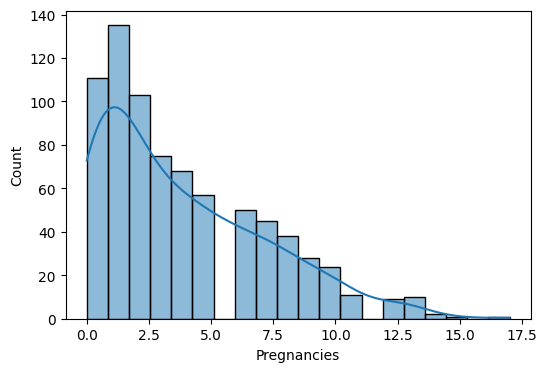

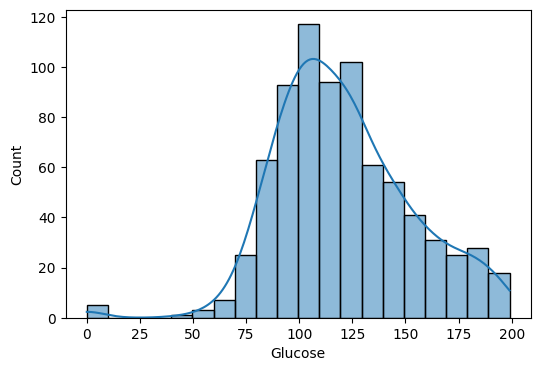

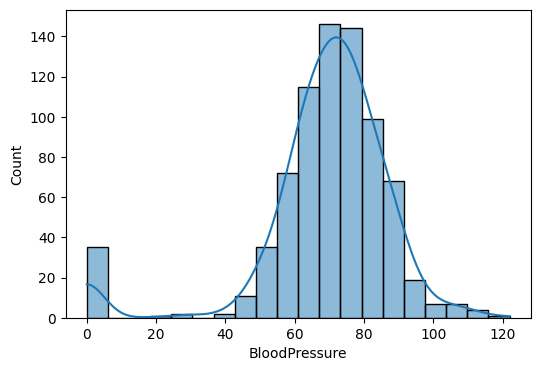

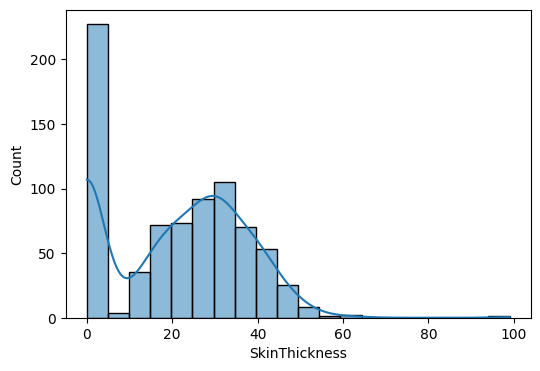

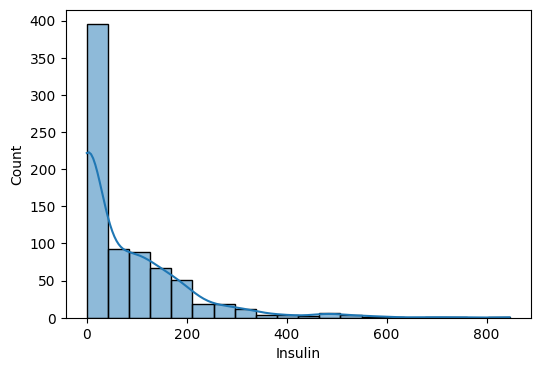

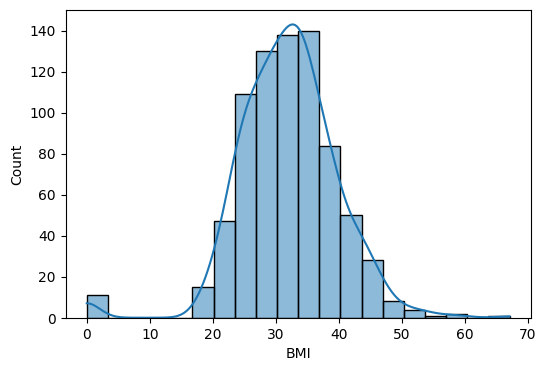

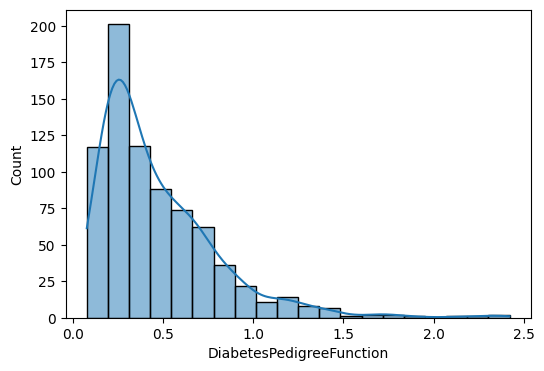

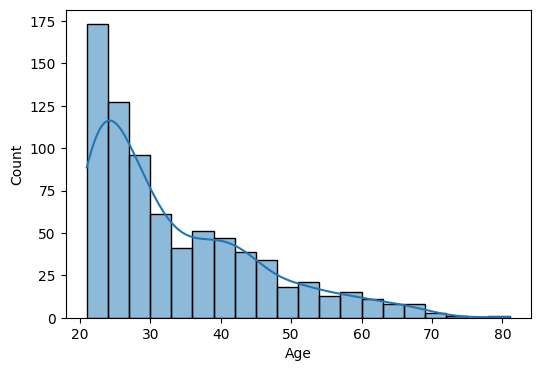

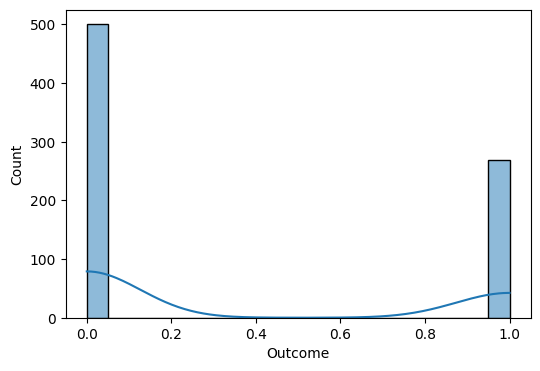

In [14]:
numeric_columns=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde= True,bins=20)

<Axes: xlabel='Outcome', ylabel='count'>

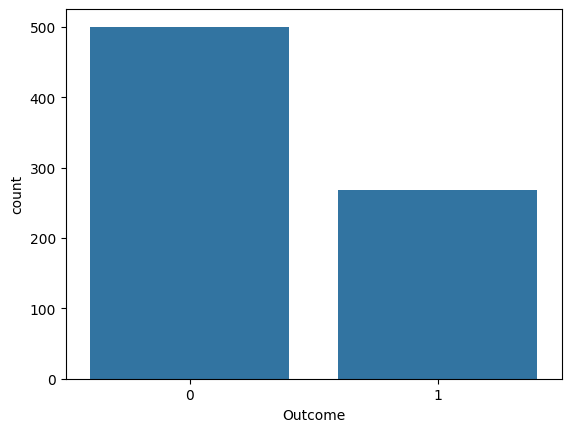

In [16]:
sns.countplot(x='Outcome', data=df)

<Axes: >

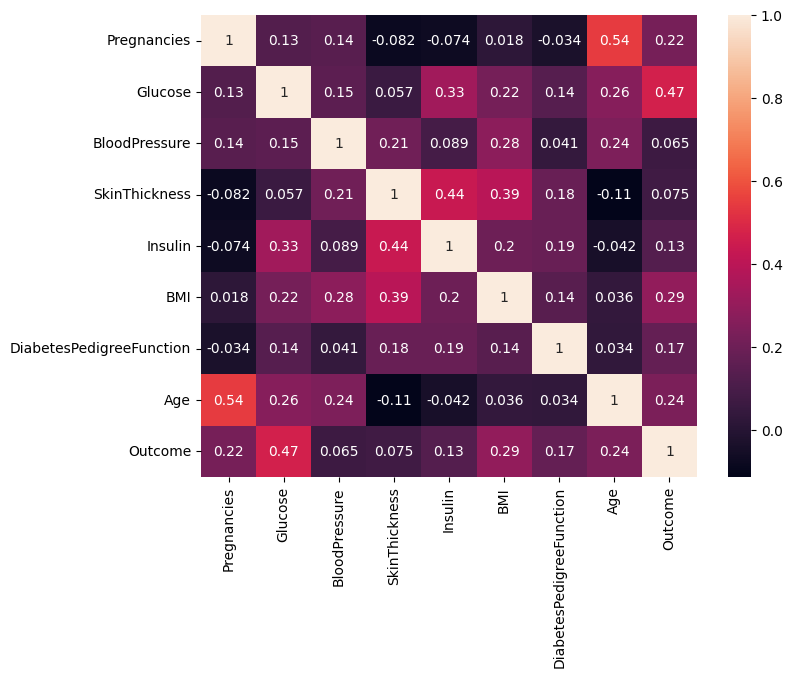

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only= True),annot=True)

In [18]:
(df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [19]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in cols:
    df[col] = df[col].replace(0, df[col].median())

In [115]:
(df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] == 0).sum()

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

In [23]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [26]:
x=df.drop('Outcome',axis=1)
y=df['Outcome']

In [30]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [41]:
x_train

array([[-0.85135507, -1.05642747, -0.82674004, ..., -0.76881064,
         0.31079384, -0.79216928],
       [ 0.35657564,  0.14439907,  0.47777235, ..., -0.41684116,
        -0.11643851,  0.56103382],
       [-0.5493724 , -0.55608308, -1.15286813, ...,  0.36042477,
        -0.76486207, -0.70759409],
       ...,
       [-0.85135507, -0.82293342, -0.17448384, ...,  0.82971741,
        -0.78607218, -0.28471812],
       [ 1.86648903, -0.35594533, -0.17448384, ..., -0.72481445,
        -1.01938346,  0.56103382],
       [ 0.05459296,  0.74481233, -1.15286813, ..., -0.43150656,
        -0.57700104,  0.30730824]], shape=(614, 8))

In [42]:
x_test

array([[ 0.96054099,  1.24515673, -0.66367599, ..., -0.73947985,
        -0.55579092,  0.56103382],
       [ 1.86648903, -1.79026591,  2.76066903, ...,  0.44841714,
        -0.58306107,  1.15306018],
       [-0.5493724 ,  0.01097389,  0.3147083 , ...,  0.50707872,
         0.01688223, -0.6230189 ],
       ...,
       [-0.5493724 , -1.32327781, -1.64206028, ..., -0.5781605 ,
         3.70138246, -0.70759409],
       [ 0.05459296,  2.07906404,  0.47777235, ...,  0.66839806,
        -0.64669142, -0.20014293],
       [-0.85135507, -1.69019703,  0.47777235, ...,  0.11111306,
        -0.16794879, -1.04589487]], shape=(154, 8))

In [34]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [35]:
y_pred=lr.predict(x_test)

In [39]:
lr.score(x_train,y_train)

0.7931596091205212

In [40]:
lr.score(x_test,y_test)

0.7077922077922078

In [44]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)

knn.fit(x_train, y_train)

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [46]:
pred=knn.predict(x_test)

In [47]:
knn.score(x_train,y_train)

0.8094462540716613

In [49]:
knn.score(x_test,y_test)

0.6948051948051948

In [51]:
from sklearn.svm import SVC
svm = SVC(kernel='rbf', C=1)
svm.fit(x_train, y_train)

,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [52]:
pred=knn.predict(x_test)

In [53]:
svm.score(x_train,y_train)

0.8452768729641694

In [54]:
svm.score(x_test,y_test)

0.7337662337662337

In [56]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(
    penalty='l2',
    C=0.1,
    max_iter=1000
)
lr.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [59]:
lr.score(x_train,y_train)

0.7899022801302932

In [57]:
lr.score(x_test,y_test)

0.7077922077922078

In [61]:
lr = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=0.1,
    max_iter=1000
)
lr.fit(x_train, y_train)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [62]:
lr.score(x_train,y_train)

0.7882736156351792

In [63]:
lr.score(x_test,y_test)

0.7077922077922078

In [66]:
from sklearn.metrics import accuracy_score
train_pred = lr.predict(x_train)
test_pred = lr.predict(x_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, test_pred))

Train Accuracy: 0.7882736156351792
Test Accuracy : 0.7077922077922078


In [73]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

for k in range(3, 26, 2):
    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(x_train, y_train)

    train_acc = accuracy_score(y_train, knn.predict(x_train))
    test_acc = accuracy_score(y_test, knn.predict(x_test))

    print(f"k={k} | Train={train_acc:.4f} | Test={test_acc:.4f}")

k=3 | Train=0.8388 | Test=0.7013
k=5 | Train=0.8274 | Test=0.7078
k=7 | Train=0.8094 | Test=0.6948
k=9 | Train=0.8046 | Test=0.6948
k=11 | Train=0.8078 | Test=0.7078
k=13 | Train=0.8143 | Test=0.7143
k=15 | Train=0.8078 | Test=0.7403
k=17 | Train=0.8029 | Test=0.7338
k=19 | Train=0.7964 | Test=0.7468
k=21 | Train=0.7964 | Test=0.7662
k=23 | Train=0.8046 | Test=0.7532
k=25 | Train=0.7997 | Test=0.7532


In [71]:
train_acc = accuracy_score(y_train, knn.predict(x_train))
test_acc = accuracy_score(y_test, knn.predict(x_test))
train_acc

0.7996742671009772

In [72]:
test_acc

0.7532467532467533

In [78]:
knn = KNeighborsClassifier(n_neighbors=21) 
knn.fit(x_train, y_train)
print("Train Accuracy:", accuracy_score(y_train, knn.predict(x_train)))
print("Test Accuracy :", accuracy_score(y_test, knn.predict(x_test)))

Train Accuracy: 0.7964169381107492
Test Accuracy : 0.7662337662337663


In [79]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

for c in [0.01, 0.1, 1, 10]:
    svm = SVC(
        kernel='rbf',
        C=c,
        random_state=42
    )

    svm.fit(x_train, y_train)

    train_acc = accuracy_score(y_train, svm.predict(x_train))
    test_acc = accuracy_score(y_test, svm.predict(x_test))

    print(f"C={c} | Train={train_acc:.4f} | Test={test_acc:.4f}")

C=0.01 | Train=0.6515 | Test=0.6494
C=0.1 | Train=0.7899 | Test=0.7338
C=1 | Train=0.8453 | Test=0.7338
C=10 | Train=0.8844 | Test=0.7273


In [84]:
train_acc


0.8843648208469055

In [83]:
test_acc

0.7272727272727273

In [81]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(svm, x, y, cv=5)
print("CV Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

CV Scores: [0.74675325 0.70779221 0.77922078 0.79084967 0.75163399]
Mean CV Accuracy: 0.7552499787793906


In [86]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
rf.fit(x_train, y_train)
print("Train:", accuracy_score(y_train, rf.predict(x_train)))
print("Test :", accuracy_score(y_test, rf.predict(x_test)))

Train: 0.7980456026058632
Test : 0.7337662337662337


In [103]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    'n_neighbors': list(range(3, 31, 2)),
    'weights': ['uniform'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_knn.fit(x_train, y_train)

print("Best Parameters:", grid_knn.best_params_)
print("Best CV Score:", grid_knn.best_score_)

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 19, 'weights': 'uniform'}
Best CV Score: 0.7834332933493269


In [106]:
from sklearn.metrics import accuracy_score

best_knn = grid_knn.best_estimator_

train_acc = accuracy_score(y_train, best_knn.predict(x_train))
test_acc = accuracy_score(y_test, best_knn.predict(x_test))

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

Train Accuracy: 0.7964169381107492
Test Accuracy : 0.7467532467532467


In [92]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_svm.fit(x_train, y_train)

print("Best Parameters:", grid_svm.best_params_)
print("Best CV Score:", grid_svm.best_score_)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Score: 0.7801679328268692


In [94]:
best_svm = grid_svm.best_estimator_

train_acc = accuracy_score(y_train, best_svm.predict(x_train))
test_acc = accuracy_score(y_test, best_svm.predict(x_test))

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

Train Accuracy: 0.7882736156351792
Test Accuracy : 0.7077922077922078


In [98]:
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(x_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best CV Score:", grid_rf.best_score_)

Best Parameters: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best CV Score: 0.7801945888311342


In [99]:
best_rf = grid_rf.best_estimator_

train_acc = accuracy_score(y_train, best_rf.predict(x_train))
test_acc = accuracy_score(y_test, best_rf.predict(x_test))

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

Train Accuracy: 0.8957654723127035
Test Accuracy : 0.7337662337662337


In [101]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['KNN', 'SVM', 'Random Forest'],
    'Train Accuracy': [
        accuracy_score(y_train, best_knn.predict(x_train)),
        accuracy_score(y_train, best_svm.predict(x_train)),
        accuracy_score(y_train, best_rf.predict(x_train))
    ],
    'Test Accuracy': [
        accuracy_score(y_test, best_knn.predict(x_test)),
        accuracy_score(y_test, best_svm.predict(x_test)),
        accuracy_score(y_test, best_rf.predict(x_test))
    ]
})

print(results)

           Model  Train Accuracy  Test Accuracy
0            KNN        1.000000       0.727273
1            SVM        0.788274       0.707792
2  Random Forest        0.895765       0.733766


In [121]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.9 MB/s eta 0:00:55
    --------------------------------------- 1.3/101.7 MB 2.9 MB/s eta 0:00:35
    --------------------------------------- 2.1/101.7 MB 3.4 MB/s eta 0:00:30
   - -------------------------------------- 2.9/101.7 MB 3.4 MB/s eta 0:00:30
   - -------------------------------------- 3.9/101.7 MB 3.6 MB/s eta 0:00:28
   - -------------------------------------- 4.7/101.7 MB 3.6 MB/s eta 0:00:27
   -- ------------------------------------- 5.5/101.7 MB 3.6 MB/s eta 0:00:27
   -- ------------------------------------- 6.3/101.7 MB 3.6 MB/s eta 0:00:27
   -- ------------------------------------- 7.1/101.7 MB 3.7 MB/s eta 0:00:26
   --- ------------------------------------ 7.9/101.7 MB 3.7 MB/s eta 0:00:26
   --- ------------------------------------ 8.9/101.7 MB 3.8 MB/s eta 0:00:25
   --- ------------------------------------ 9.7/101.7 MB 3.8 MB/s eta 0


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [127]:
df['BMI_Age'] = df['BMI'] * df['Age']
df['Glucose_BMI'] = df['Glucose'] * df['BMI']
df['Preg_Age'] = df['Pregnancies'] * df['Age']

In [135]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

param_grid = {
    'n_estimators':[50,100,200],
    'max_depth':[2,3,4],
    'learning_rate':[0.01,0.05,0.1],
    'subsample':[0.8,1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_xgb.fit(x_train, y_train)

print("Best Parameters:", grid_xgb.best_params_)
print("Best CV Score:", grid_xgb.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 50, 'subsample': 0.8}
Best CV Score: 0.7720511795281888


In [137]:
from sklearn.metrics import accuracy_score

best_xgb = grid_xgb.best_estimator_

train_acc = accuracy_score(
    y_train,
    best_xgb.predict(x_train)
)

test_acc = accuracy_score(
    y_test,
    best_xgb.predict(x_test)
)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

Train Accuracy: 0.8175895765472313
Test Accuracy : 0.7272727272727273


In [122]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(x_train, y_train)

print("Train:", accuracy_score(y_train, xgb.predict(x_train)))
print("Test :", accuracy_score(y_test, xgb.predict(x_test)))

Train: 0.8892508143322475
Test : 0.7467532467532467


In [124]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(x_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [126]:
print("Train:", accuracy_score(y_train, gb.predict(x_train)))
print("Test :", accuracy_score(y_test, gb.predict(x_test)))

Train: 0.9201954397394136
Test : 0.7597402597402597


In [138]:
from sklearn.neighbors import KNeighborsClassifier

final_model = KNeighborsClassifier(
    n_neighbors=21,
    weights='uniform'
)

final_model.fit(x_train, y_train)

,n_neighbors,21
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [139]:
final_model.score(x_train,y_train)

0.7964169381107492

In [140]:
final_model.score(x_test,y_test)

0.7662337662337663

In [141]:
import joblib

joblib.dump(final_model, "diabetes_knn_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']